In [1]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from compute_transport import *
from simulate_data import *
from evaluation_metrics import *
from benchmark_scalability import *
import torch
import torch.nn.functional as F
from evaluation_metrics import *
import json
import pickle
import os
from refcm import RefCM
from refcm.embeddings import HVGEmbedder
import anndata

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(20, 10), facecolor='white')

In [16]:
# %%
def load_optimal_parameters(parameter_file: str = "./Parameter_Selection/optimal_parameters.json") -> dict:
    """
    Load pre-selected optimal parameters from file.
    """
    if not os.path.exists(parameter_file):
        raise FileNotFoundError(f"Parameter file not found: {parameter_file}")
    
    if parameter_file.endswith('.json'):
        with open(parameter_file, 'r') as f:
            params = json.load(f)
        # Convert string keys to integers
        params = {int(k): v for k, v in params.items()}
    elif parameter_file.endswith('.pkl'):
        with open(parameter_file, 'rb') as f:
            params = pickle.load(f)
    else:
        raise ValueError("Parameter file must be .json or .pkl")
    
    print("Loaded optimal parameters:")
    for n_types, p in sorted(params.items()):
        print(f"  {n_types} types: α={p['temperature']:.4f}, λ={p['mesh_lr']:.1f}, "
              f"T={p['n_mesh_iters']}, n_sh={p['n_sh_iters']}")
    
    return params

# %%
def benchmark_single_configuration_with_params(
    n_types: int,
    optimal_params: dict,
    n_cells_per_type: int = 50,
    noise_level: float = 1.0,
    n_runs: int = 3
) -> dict:
    """
    Benchmark all methods using pre-selected optimal parameters.
    """
    # Get parameters for this n_types
    if n_types not in optimal_params:
        raise ValueError(f"No optimal parameters found for {n_types} types")
    
    ot_params = optimal_params[n_types]
    
    print(f"  Using pre-selected parameters: α={ot_params['temperature']:.4f}, "
          f"λ={ot_params['mesh_lr']:.1f}, T={ot_params['n_mesh_iters']}")
    
    results = {
        'ot_mesh': {'time': [], 'accuracy': [], 'sparseness': [], 'entropy': [], 'ari': []},
        'ot_vanilla': {'time': [], 'accuracy': [], 'sparseness': [], 'entropy': [], 'ari': []},
        'xgboost': {'time': [], 'accuracy': [], 'sparseness': [], 'entropy': [], 'ari': []},
        'harmony': {'time': [], 'accuracy': [], 'sparseness': [], 'entropy': [], 'ari': []},
        'refcm_strict': {'time': [], 'accuracy': [], 'sparseness': [], 'entropy': [], 'ari': []},
        'refcm_flex': {'time': [], 'accuracy': [], 'sparseness': [], 'entropy': [], 'ari': []}
    }
    
    for run in range(n_runs):
        print(f"  Run {run + 1}/{n_runs}")
        
        # Create matched datasets
        adata1, adata2, W_true = create_matched_species(
            n_types=n_types,
            n_cells_per_type=n_cells_per_type,
            noise_level=noise_level,
            scaling_method='uniform',
            scale_range=(0.8, 1.2),
            seed=42 + run
        )
        
        # Normalize and log-transform
        sc.pp.normalize_total(adata1, target_sum=1e4)
        sc.pp.log1p(adata1)
        sc.pp.normalize_total(adata2, target_sum=1e4)
        sc.pp.log1p(adata2)
        
        # Prepare data
        df1, df2, type_map1, type_map2 = prepare_data_for_methods(adata1, adata2)
        
        # Get common genes
        common_genes = list(set(df1.columns) & set(df2.columns))
        
        # Select SNR genes
        df_combined = pd.concat([df1[common_genes], df2[common_genes]], axis=0)
        snr_genes = compute_snr_genes(df_combined, threshold=5)
        
        # Adaptive gene selection
        if n_types <= 50:
            n_genes_use = min(20, len(snr_genes))
        elif n_types <= 100:
            n_genes_use = min(50, len(snr_genes))
        else:
            n_genes_use = min(100, len(snr_genes))
        
        if len(snr_genes) == 0:
            print(f"    Warning: No SNR genes found, using top common genes")
            snr_genes = common_genes[:n_genes_use]
        else:
            snr_genes = snr_genes[:n_genes_use]
        
        print(f"    Using {len(snr_genes)} SNR genes")
        
        # Compute distance matrix
        distance_matrix = compute_distance_matrix(df1, df2, snr_genes)
        
        # 1. OT-MESH with pre-selected parameters
        try:
            start = time.time()
            W_mesh = compute_sparse_transport(
                distance_matrix,
                mesh_lr=ot_params['mesh_lr'],
                n_mesh_iters=ot_params['n_mesh_iters'],
                temperature=ot_params['temperature'],
                n_sh_iters=ot_params['n_sh_iters']
            )
            time_mesh = time.time() - start
            
            if isinstance(W_mesh, pd.DataFrame):
                W_mesh = W_mesh.values
            
            metrics = compute_accuracy_metrics(W_mesh, W_true)
            
            results['ot_mesh']['time'].append(time_mesh)
            for key in ['accuracy', 'sparseness', 'entropy', 'ari']:
                results['ot_mesh'][key].append(metrics[key])
                
        except Exception as e:
            print(f"    OT-MESH failed: {e}")
            results['ot_mesh']['time'].append(np.nan)
            for key in ['accuracy', 'sparseness', 'entropy', 'ari']:
                results['ot_mesh'][key].append(np.nan)
        
        # 2. Vanilla OT (use same temperature)
        try:
            start = time.time()
            W_vanilla = compute_regular_transport(
                distance_matrix,
                temperature=ot_params['temperature'],
                n_sh_iters=ot_params['n_sh_iters']
            )
            time_vanilla = time.time() - start
            
            if isinstance(W_vanilla, pd.DataFrame):
                W_vanilla = W_vanilla.values
            
            metrics = compute_accuracy_metrics(W_vanilla, W_true)
            
            results['ot_vanilla']['time'].append(time_vanilla)
            for key in ['accuracy', 'sparseness', 'entropy', 'ari']:
                results['ot_vanilla'][key].append(metrics[key])
                
        except Exception as e:
            print(f"    Vanilla OT failed: {e}")
            results['ot_vanilla']['time'].append(np.nan)
            for key in ['accuracy', 'sparseness', 'entropy', 'ari']:
                results['ot_vanilla'][key].append(np.nan)
        
        # 3. XGBoost (skip for very large datasets)
        if n_types >= 1000:
            results['xgboost']['time'].append(np.nan)
            for key in ['accuracy', 'sparseness', 'entropy', 'ari']:
                results['xgboost'][key].append(np.nan)
        else:
            try:
                labels1 = df1.index.values
                labels2 = df2.index.values
                
                start = time.time()
                cm_xgb, model = transcriptome_mapping(
                    df1[snr_genes],
                    df2[snr_genes], 
                    labels1, 
                    labels2,
                    mk_species="Species1", 
                    ms_species="Species2",
                    train_frac=0.6,
                    n_round=1,
                    max_cells_per_type=min(50, n_cells_per_type)
                )
                time_xgb = time.time() - start
                
                if isinstance(cm_xgb, pd.DataFrame):
                    cm_xgb = cm_xgb.values
                W_xgb = cm_xgb / (cm_xgb.sum() + 1e-10)
                
                metrics = compute_accuracy_metrics(W_xgb, W_true)
                
                results['xgboost']['time'].append(time_xgb)
                for key in ['accuracy', 'sparseness', 'entropy', 'ari']:
                    results['xgboost'][key].append(metrics[key])
                    
            except Exception as e:
                print(f"    XGBoost failed: {e}")
                results['xgboost']['time'].append(np.nan)
                for key in ['accuracy', 'sparseness', 'entropy', 'ari']:
                    results['xgboost'][key].append(np.nan)
        
        # 4. Harmony + 1NN (skip for very large datasets)
        if n_types >= 1000:
            results['harmony']['time'].append(np.nan)
            for key in ['accuracy', 'sparseness', 'entropy', 'ari']:
                results['harmony'][key].append(np.nan)
        else:
            try:
                n_pca = min(50, len(snr_genes) - 1, df1.shape[0] - 1)
                labels1 = df1.index.values
                labels2 = df2.index.values
                
                start = time.time()
                cm_harmony = harmony_1nn_mapping(
                    df1[snr_genes], 
                    df2[snr_genes], 
                    labels1, 
                    labels2,
                    source_name="Species1", 
                    target_name="Species2",
                    n_comps=n_pca
                )
                time_harmony = time.time() - start
                
                if isinstance(cm_harmony, pd.DataFrame):
                    cm_harmony = cm_harmony.values
                W_harmony = cm_harmony / (cm_harmony.sum() + 1e-10)
                
                metrics = compute_accuracy_metrics(W_harmony, W_true)
                
                results['harmony']['time'].append(time_harmony)
                for key in ['accuracy', 'sparseness', 'entropy', 'ari']:
                    results['harmony'][key].append(metrics[key])
                    
            except Exception as e:
                print(f"    Harmony failed: {e}")
                results['harmony']['time'].append(np.nan)
                for key in ['accuracy', 'sparseness', 'entropy', 'ari']:
                    results['harmony'][key].append(np.nan)
        
        # 5. RefCM-Strict (1-to-1 mapping)
        if n_types >= 1000:
            results['refcm_strict']['time'].append(np.nan)
            for key in ['accuracy', 'sparseness', 'entropy', 'ari']:
                results['refcm_strict'][key].append(np.nan)
        else:
            try:
                # Prepare data for RefCM
                query_adata = prepare_simulated_data_for_refcm(df1[snr_genes], 'cell_type')
                ref_adata = prepare_simulated_data_for_refcm(df2[snr_genes], 'cell_type')
                
                # Initialize RefCM with strict 1-to-1 mapping
                refcm_strict = RefCM(
                    max_merges=1,
                    max_splits=1,
                    discovery_threshold=0.0,
                    verbose_solver=False,
                    embedder=HVGEmbedder(n_top_genes=len(snr_genes)),
                    cache_save=False,
                    cache_load=False
                )
                
                # Set reference
                refcm_strict.setref(ref_adata, ref_id='species2', ref_key='cell_type')
                
                # Time the annotation
                start = time.time()
                matching = refcm_strict.annotate(query_adata, q_id='species1', q_key='cell_type')
                time_refcm = time.time() - start
                
                # Extract and process mapping matrix (same as before)
                mapping_matrix = query_adata.uns['refcm_mapping']
                W_refcm = mapping_matrix / (mapping_matrix.sum() + 1e-10)
                
                # Reorder to match true correspondence
                unique_types1 = sorted(df1.index.unique())
                unique_types2 = sorted(df2.index.unique())
                W_refcm_ordered = np.zeros((len(unique_types1), len(unique_types2)))
                
                for i, t1 in enumerate(unique_types1):
                    for j, t2 in enumerate(unique_types2):
                        cluster_idx1 = list(query_adata.obs['cell_type'].unique()).index(t1)
                        cluster_idx2 = list(ref_adata.obs['cell_type'].unique()).index(t2)
                        if cluster_idx1 < W_refcm.shape[0] and cluster_idx2 < W_refcm.shape[1]:
                            W_refcm_ordered[i, j] = W_refcm[cluster_idx1, cluster_idx2]
                
                metrics = compute_accuracy_metrics(W_refcm_ordered, W_true)
                
                results['refcm_strict']['time'].append(time_refcm)
                for key in ['accuracy', 'sparseness', 'entropy', 'ari']:
                    results['refcm_strict'][key].append(metrics[key])
                    
            except Exception as e:
                print(f"    RefCM-Strict failed: {e}")
                results['refcm_strict']['time'].append(np.nan)
                for key in ['accuracy', 'sparseness', 'entropy', 'ari']:
                    results['refcm_strict'][key].append(np.nan)
        
        # 6. RefCM-Flexible (allowing complex mappings)
        if n_types >= 1000:
            results['refcm_flex']['time'].append(np.nan)
            for key in ['accuracy', 'sparseness', 'entropy', 'ari']:
                results['refcm_flex'][key].append(np.nan)
        else:
            try:
                # Prepare data for RefCM (fresh copy)
                query_adata_flex = prepare_simulated_data_for_refcm(df1[snr_genes], 'cell_type')
                ref_adata_flex = prepare_simulated_data_for_refcm(df2[snr_genes], 'cell_type')
                
                # Calculate flexible parameters (10% of number of types)
                max_complex = max(2, int(0.1 * n_types))  # At least 2, but 10% of types
                
                # Initialize RefCM with flexible mapping
                refcm_flex = RefCM(
                    max_merges=max_complex,
                    max_splits=max_complex,
                    discovery_threshold=0.5,  # Higher threshold for discovery
                    verbose_solver=False,
                    embedder=HVGEmbedder(n_top_genes=len(snr_genes)),
                    cache_save=False,
                    cache_load=False
                )
                
                # Set reference
                refcm_flex.setref(ref_adata_flex, ref_id='species2', ref_key='cell_type')
                
                # Time the annotation
                start = time.time()
                matching_flex = refcm_flex.annotate(query_adata_flex, q_id='species1', q_key='cell_type')
                time_refcm_flex = time.time() - start
                
                # Extract and process mapping matrix
                mapping_matrix_flex = query_adata_flex.uns['refcm_mapping']
                W_refcm_flex = mapping_matrix_flex / (mapping_matrix_flex.sum() + 1e-10)
                
                # Reorder to match true correspondence
                W_refcm_flex_ordered = np.zeros((len(unique_types1), len(unique_types2)))
                
                for i, t1 in enumerate(unique_types1):
                    for j, t2 in enumerate(unique_types2):
                        cluster_idx1 = list(query_adata_flex.obs['cell_type'].unique()).index(t1)
                        cluster_idx2 = list(ref_adata_flex.obs['cell_type'].unique()).index(t2)
                        if cluster_idx1 < W_refcm_flex.shape[0] and cluster_idx2 < W_refcm_flex.shape[1]:
                            W_refcm_flex_ordered[i, j] = W_refcm_flex[cluster_idx1, cluster_idx2]
                
                metrics_flex = compute_accuracy_metrics(W_refcm_flex_ordered, W_true)
                
                results['refcm_flex']['time'].append(time_refcm_flex)
                for key in ['accuracy', 'sparseness', 'entropy', 'ari']:
                    results['refcm_flex'][key].append(metrics_flex[key])
                    
            except Exception as e:
                print(f"    RefCM-Flexible failed: {e}")
                results['refcm_flex']['time'].append(np.nan)
                for key in ['accuracy', 'sparseness', 'entropy', 'ari']:
                    results['refcm_flex'][key].append(np.nan)
    
    # Average over runs
    averaged_results = {}
    for method in results:
        averaged_results[method] = {}
        for metric in results[method]:
            values = [v for v in results[method][metric] if not np.isnan(v)]
            if values:
                averaged_results[method][metric] = np.mean(values)
                averaged_results[method][f'{metric}_std'] = np.std(values)
            else:
                averaged_results[method][metric] = np.nan
                averaged_results[method][f'{metric}_std'] = np.nan
    
    # Store the parameters used
    averaged_results['params_used'] = ot_params
    
    return averaged_results

# %%
def run_full_scalability_benchmark_with_params():
    """
    Run complete scalability benchmark using pre-selected parameters.
    """
    # Load optimal parameters
    try:
        optimal_params = load_optimal_parameters("./Parameter_Selection/optimal_parameters.json")
    except FileNotFoundError:
        print("ERROR: Parameter file not found!")
        print("Please run parameter selection first.")
        return None
    
    n_types_list = [20, 50, 100, 200, 500]
    n_cells_per_type = 50
    
    all_results = []
    
    for n_types in n_types_list:
        if n_types not in optimal_params:
            print(f"Warning: No parameters for {n_types} types, skipping...")
            continue
            
        print(f"\n{'='*50}")
        print(f"Testing with {n_types} cell types...")
        print(f"{'='*50}")
        
        n_runs = 3
        
        results = benchmark_single_configuration_with_params(
            n_types=n_types,
            optimal_params=optimal_params,
            n_cells_per_type=n_cells_per_type,
            n_runs=n_runs
        )
        
        results['n_types'] = n_types
        results['n_cells'] = n_types * n_cells_per_type
        
        all_results.append(results)
        
        # Print summary
        print(f"\nResults for {n_types} types:")
        for method in ['ot_mesh', 'ot_vanilla', 'xgboost', 'harmony', 'refcm_strict', 'refcm_flex']:
            if method in results and not np.isnan(results[method]['time']):
                print(f"{method:14} - Time: {results[method]['time']:.3f}s, "
                      f"ARI: {results[method]['ari']:.3f}, "
                      f"Sparse: {results[method]['sparseness']:.3f}, "
                      f"Entropy: {results[method]['entropy']:.3f}")
    
    return all_results

# %%
def plot_scalability_results(results: list, output_dir: str = './Scalability'):
    """
    Create publication-quality plots for scalability analysis with error bars.
    """
    df_list = []
    for r in results:
        n_types = r['n_types']
        for method in ['ot_mesh', 'ot_vanilla', 'xgboost', 'harmony', 'refcm_strict', 'refcm_flex']:
            if method in r and not np.isnan(r[method]['time']):
                df_list.append({
                    'n_types': n_types,
                    'method': method,
                    'time': r[method]['time'],
                    'time_std': r[method].get('time_std', 0),  # Extract std properly
                    'ari': r[method]['ari'],
                    'ari_std': r[method].get('ari_std', 0),  # Extract std properly
                    'entropy': r[method]['entropy'],
                    'entropy_std': r[method].get('entropy_std', 0)  # Extract std properly
                })
    
    df = pd.DataFrame(df_list)
    # Filter to only include 50+ types as specified
    df = df[df['n_types'] >= 50]
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    
    colors = {
        'ot_mesh': '#2E86AB', 
        'ot_vanilla': '#A23B72', 
        'xgboost': '#F18F01', 
        'harmony': '#C73E1D',
        'refcm_strict': '#4CAF50',
        'refcm_flex': '#8BC34A'
    }

    method_labels = {
        'ot_mesh': 'OT-MESH',
        'ot_vanilla': 'OT without MESH',
        'xgboost': 'XGBoost',
        'harmony': 'Harmony+1NN',
        'refcm_strict': 'RefCM-Strict',
        'refcm_flex': 'RefCM-Flexible'
    }
    
    # 1. Runtime scaling with error bars
    ax = axes[0]
    for method in df['method'].unique():
        data = df[df['method'] == method].sort_values('n_types')
        ax.errorbar(data['n_types'], data['time'], 
                    yerr=data['time_std'],  # Use the std as error bars
                    label=method_labels.get(method, method), 
                    color=colors.get(method, 'gray'),
                    marker='o', linewidth=2, markersize=8, 
                    capsize=5, capthick=2, alpha=0.8)
    ax.set_xlabel('Number of Cell Types', fontsize=12)
    ax.set_ylabel('Runtime (seconds)', fontsize=12)
    ax.set_title('Computational Scaling', fontsize=13, fontweight='bold')
    ax.set_yscale('log')
    ax.set_xticks([50, 100, 200, 500])
    ax.grid(True, alpha=0.3)
    
    # 2. ARI with error bars
    ax = axes[1]
    for method in df['method'].unique():
        data = df[df['method'] == method].sort_values('n_types')
        ax.errorbar(data['n_types'], data['ari'], 
                    yerr=data['ari_std'],  # Use the std as error bars
                    label=method_labels.get(method, method),
                    color=colors.get(method, 'gray'),
                    marker='s', linewidth=2, markersize=8,
                    capsize=5, capthick=2, alpha=0.8)
    ax.set_xlabel('Number of Cell Types', fontsize=12)
    ax.set_ylabel('Adjusted Rand Index', fontsize=12)
    ax.set_title('Matching Accuracy', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1.05])
    ax.set_xticks([50, 100, 200, 500])
    ax.grid(True, alpha=0.3)
    
    # 3. Entropy with error bars
    ax = axes[2]
    for method in df['method'].unique():
        data = df[df['method'] == method].sort_values('n_types')
        ax.errorbar(data['n_types'], data['entropy'],
                    yerr=data['entropy_std'],  # Use the std as error bars
                    label=method_labels.get(method, method),
                    color=colors.get(method, 'gray'),
                    marker='^', linewidth=2, markersize=8,
                    capsize=5, capthick=2, alpha=0.8)
    ax.set_xlabel('Number of Cell Types', fontsize=12)
    ax.set_ylabel('Entropy', fontsize=12)
    ax.set_title('Solution Entropy', fontsize=13, fontweight='bold')
    ax.set_yscale('log')
    ax.set_xticks([50, 100, 200, 500])
    ax.legend(frameon=True, fancybox=True, shadow=True, loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/scalability_plots.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig

In [4]:
# Run benchmark with pre-selected parameters
print("Starting scalability benchmark with pre-selected parameters...")
print("This will take several minutes to complete.")

results = run_full_scalability_benchmark_with_params()

if results:
    print("Benchmark succeeded.")
else:
    print("Benchmark failed - please check parameter files.")

Starting scalability benchmark with pre-selected parameters...
This will take several minutes to complete.
Loaded optimal parameters:
  20 types: α=0.5000, λ=5.0, T=8, n_sh=5
  50 types: α=0.5000, λ=10.0, T=10, n_sh=5
  100 types: α=0.1000, λ=10.0, T=14, n_sh=5
  200 types: α=0.1000, λ=10.0, T=14, n_sh=5
  500 types: α=0.1000, λ=50.0, T=14, n_sh=5

Testing with 20 cell types...
  Using pre-selected parameters: α=0.5000, λ=5.0, T=8
  Run 1/3
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
    Using 20 SNR genes
Processing input data...
Using 20 common genes between species
Training XGBoost model...
Validation accuracy: 0.6775
Predicting cell types for Species2...
Creating confusion matrix...
Running Harmony integration...
computing PCA
    with n_comps=19
    finished (0:00:00)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2025-08-31 14:49:01,766 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-08-31 14:49:01,963 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-08-31 14:49:01,968 - harmonypy - INFO - Iteration 1 of 10
2025-08-31 14:49:02,087 - harmonypy - INFO - Iteration 2 of 10
2025-08-31 14:49:02,207 - harmonypy - INFO - Iteration 3 of 10
2025-08-31 14:49:02,255 - harmonypy - INFO - Iteration 4 of 10
2025-08-31 14:49:02,290 - harmonypy - INFO - Iteration 5 of 10
2025-08-31 14:49:02,331 - harmonypy - INFO - Iteration 6 of 10
2025-08-31 14:49:02,440 - harmonypy - INFO - Iteration 7 of 10
2025-08-31 14:49:02,514 - harmonypy - INFO - Iteration 8 of 10
2025-08-31 14:49:02,621 - harmonypy - INFO - Iteration 9 of 10
2025-08-31 14:49:02,665 - harmonypy - INFO - Iteration 10 of 10
2025-08-31 14:49:02,701 - harmonypy - INFO - Converged after 10 iterations


Performing 1NN assignment...
Running Time: 1.201176 seconds
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


|████████████████| [100.00% ] : 00:00


extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


...

Performing 1NN assignment...
Running Time: 15.521580 seconds
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


|████████████████| [100.00% ] : 02:29


extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


|████████████████| [100.00% ] : 02:30



Results for 500 types:
ot_mesh        - Time: 0.113s, ARI: 0.853, Sparse: 0.998, Entropy: 6.824
ot_vanilla     - Time: 0.004s, ARI: -0.001, Sparse: 1.000, Entropy: 12.428
xgboost        - Time: 63.530s, ARI: 0.645, Sparse: 0.998, Entropy: 7.206
harmony        - Time: 18.266s, ARI: 0.053, Sparse: 1.000, Entropy: 9.634
refcm_strict   - Time: 162.930s, ARI: 1.000, Sparse: 0.998, Entropy: 6.215
refcm_flex     - Time: 160.742s, ARI: 0.030, Sparse: 0.999, Entropy: 7.213
Benchmark succeeded.


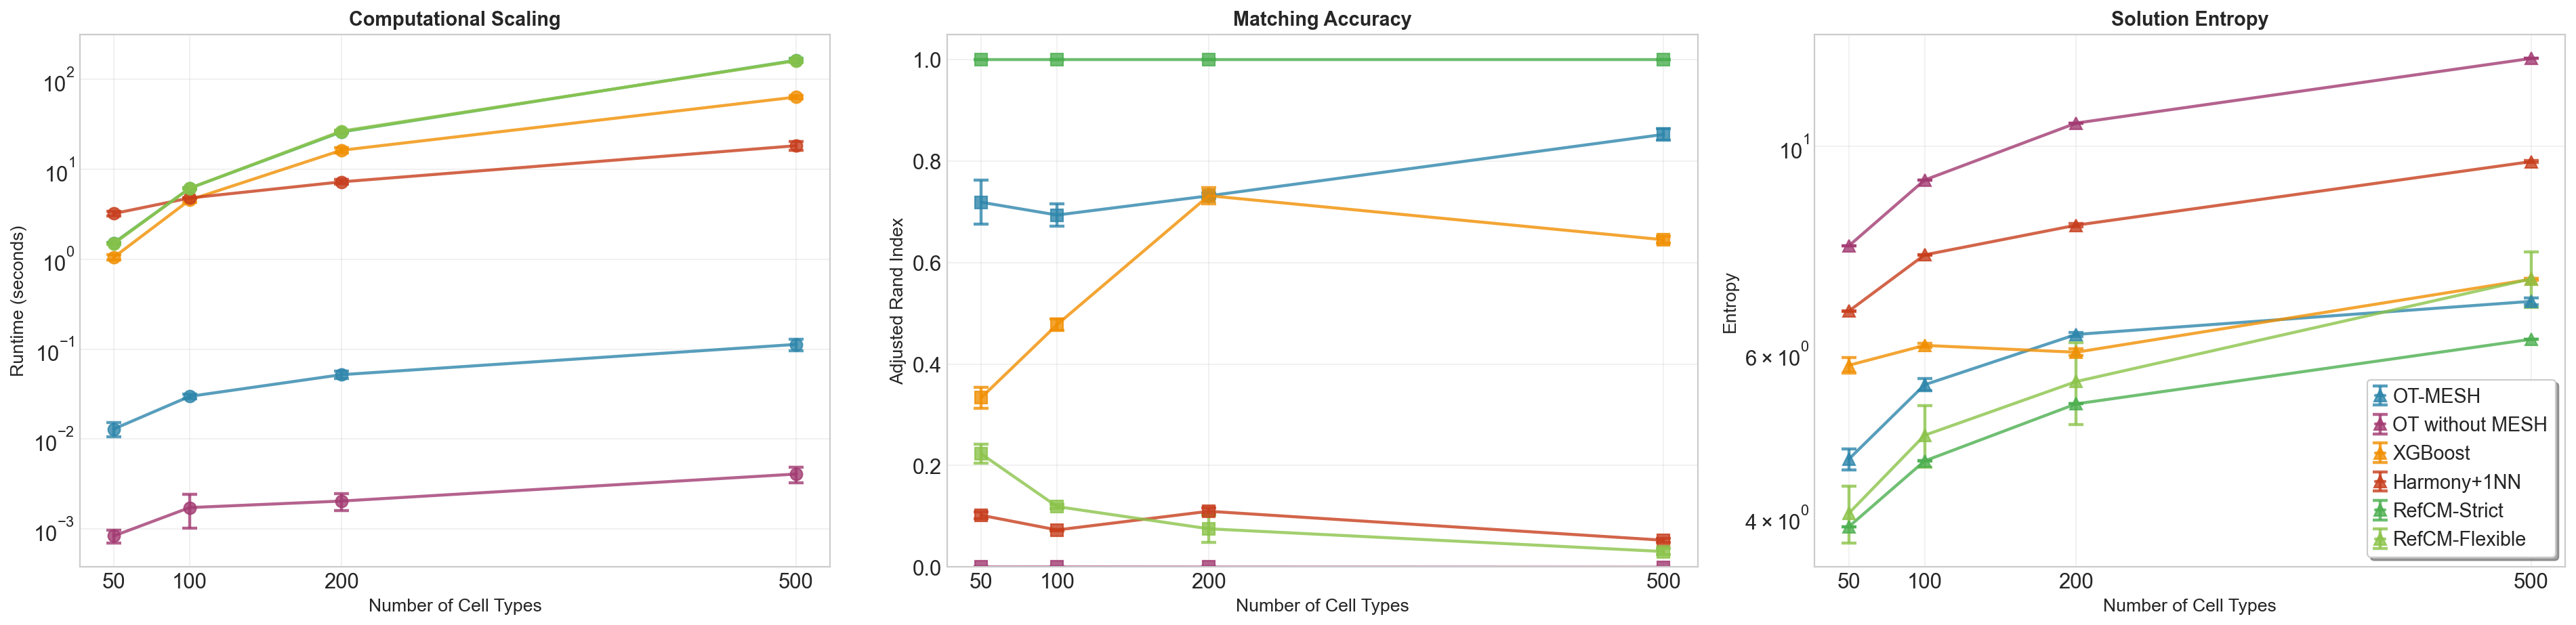


Benchmark complete!
Results saved to:
  - scalability_benchmark_results_with_params.csv
  - benchmark_parameters.csv
  - benchmark_plot.png


In [17]:
# Plot results
fig = plot_scalability_results(results)

# Save results to CSV
df_results = pd.DataFrame(results)
df_results.to_csv('./Scalability/scalability_benchmark_results_with_params.csv', index=False)

# Also save a summary of parameters used
param_summary = []
for r in results:
    if 'params_used' in r:
        param_summary.append({
            'n_types': r['n_types'],
            'temperature': r['params_used']['temperature'],
            'mesh_lr': r['params_used']['mesh_lr'],
            'n_mesh_iters': r['params_used']['n_mesh_iters'],
            'n_sh_iters': r['params_used']['n_sh_iters']
        })

pd.DataFrame(param_summary).to_csv('./Scalability/benchmark_parameters.csv', index=False)

print("\n" + "="*50)
print("Benchmark complete!")
print("Results saved to:")
print("  - scalability_benchmark_results_with_params.csv")
print("  - benchmark_parameters.csv")
print("  - benchmark_plot.png")